In [2]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import sys
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import scipy
from itertools import combinations

sys.path.insert(0, "src")

from grn import grn


In [3]:
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.optim as optim
import time
import copy
from itertools import combinations
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from sklearn.linear_model import LinearRegression

# ============================================================
# INITIALIZE GLOBAL STORAGE
# ============================================================
all_results = []
higher_order_results = [] # New list to store our high-order evaluations

for network_seed in range(10):
    np.random.seed(network_seed)

    # manually adjust GRN hyperparameters
    G = grn().add_structure(
        n=256,
        k=1,
        alpha=1e-99,
        beta=0.99,       # 1 - 1/r
        gamma=0.01,      # 1/r
        kappa=10,        # --w
        delta_in=100,
        delta_out=100,
    )

    G.simulate_rna(
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
        save=True,
    )

    x_wt = np.zeros(256)
    y_wt = G.rna

    single_ko_expression = np.zeros((G.n, G.n))
    single_ko_logfc = np.zeros((G.n, G.n))
    single_ko_convergence = {}

    for gene in tqdm(range(G.n), desc=f"Network {network_seed}: single-gene KOs"):
        result = G.ko_nodes(
            genes=[gene],
            stats=("new_rna", "logfc", "convergence"),
            s=1e-4,
            dt=1e-2,
            tmax=20000,
            burnin=5000,
            tol=1e-3,
        )

        single_ko_expression[gene, :] = result["new_rna"].flatten()
        single_ko_logfc[gene, :] = result["logfc"].flatten()
        single_ko_convergence[gene] = result["convergence"]

    x_single_ko = np.eye(G.n)
    y_single_ko = single_ko_expression
    
    # ------------------------------------------------------------
    # DOUBLE KO SIMULATION
    # ------------------------------------------------------------
    pairs = list(combinations(range(G.n), 2))

    def run_double_ko(pair):
        a, b = pair
        result = G.ko_nodes(
            genes=[a, b],
            stats=("new_rna", "logfc", "convergence"),
            s=1e-4, dt=1e-2, tmax=20000, burnin=5000, tol=1e-3,
        )
        return (
            np.asarray(result["new_rna"]).flatten(),
            np.asarray(result["logfc"]).flatten(),
            np.asarray(result["convergence"]),
        )

    results = Parallel(n_jobs=64, pre_dispatch="n_jobs", prefer="processes", verbose=0)(
        delayed(run_double_ko)(pair) for pair in pairs
    )

    double_expression = np.asarray([r[0] for r in results], dtype=np.float32)

    # prepare as training data
    pairs = np.array(pairs, dtype=np.int32)
    x_double_ko = np.zeros((pairs.shape[0], G.n))
    rows = np.arange(pairs.shape[0])
    x_double_ko[rows, pairs[:, 0]] = 1.0
    x_double_ko[rows, pairs[:, 1]] = 1.0
    y_double_ko = double_expression

    # ------------------------------------------------------------
    # HIGHER ORDER KO SIMULATION (Sets 3 to 10)
    # ------------------------------------------------------------
    select_size = 200
    higher_expression = {}
    all_select_sets = []
    X_list = []

    for set_size in tqdm(range(3, 11), desc=f"Network {network_seed}: higher-order KOs"):
        select_sets = set()
        while len(select_sets) < select_size:
            comb = tuple(sorted(np.random.choice(G.n, size=set_size, replace=False)))
            select_sets.add(comb)
        select_sets = list(select_sets)

        def run_combination_ko(comb):
            res = G.ko_nodes(genes=list(comb), stats=("new_rna",), s=1e-4, dt=1e-2, tmax=20000, burnin=5000, tol=1e-3)
            return np.asarray(res["new_rna"]).flatten()

        results_ho = Parallel(n_jobs=64, prefer="processes")(
            delayed(run_combination_ko)(combination) for combination in select_sets
        )

        higher_expression[set_size] = np.asarray(results_ho, dtype=np.float32)
        
        select_sets_arr = np.array(select_sets, dtype=np.int32)
        all_select_sets.append(select_sets_arr)

        X_subset = np.zeros((select_size, G.n), dtype=np.float32)
        rows_ho = np.arange(select_size)[:, None]
        X_subset[rows_ho, select_sets_arr] = 1.0
        X_list.append(X_subset)


    # ============================================================
    # 3 TRAINING RUNS ON THIS GRN
    # ============================================================
    for training_seed in range(3):
        torch.manual_seed(training_seed)
        device = torch.device("cpu")

        model = nn.Sequential(
            nn.Linear(256, 512), nn.GELU(),
            nn.Linear(512, 512), nn.GELU(),
            nn.Linear(512, 256)
        ).to(device)

        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

        # process data
        rng = np.random.default_rng(training_seed)
        n_pairs = pairs.shape[0]
        nt, nv = int(0.5 * n_pairs), int(0.1 * n_pairs)
        indices = rng.permutation(n_pairs)
        
        test_idx = indices[:nt]
        val_idx = indices[nt:nt + nv]
        train_idx = indices[nt + nv:]

        xtr = np.concatenate([x_wt[None, :], x_single_ko, x_double_ko[train_idx]], axis=0)
        ytr = np.concatenate([y_wt[None, :], y_single_ko, y_double_ko[train_idx]], axis=0)
        xv = x_double_ko[val_idx]
        yv = y_double_ko[val_idx]
        x_test = x_double_ko[test_idx]
        y_test = y_double_ko[test_idx]

        mean = np.mean(ytr, axis=0)
        scale = np.maximum(ytr.std(axis=0), 1e-6)
        s_ytr = (ytr - mean) / scale

        xtr_t = torch.as_tensor(xtr, dtype=torch.float32, device=device)
        s_ytr_t = torch.as_tensor(s_ytr, dtype=torch.float32, device=device)
        xv_t = torch.as_tensor(xv, dtype=torch.float32, device=device)

        # Training loop
        max_epochs = 3000
        batch_size = 256
        lr = 1e-3
        patience = 40
        min_lr = 1e-5
        lr_patience = 12

        best, best_epoch, stale, lr_stale = np.inf, 0, 0, 0
        best_model_weights = None

        for epoch in range(1, max_epochs + 1):
            model.train()
            permutation = torch.randperm(xtr_t.shape[0], device=device)
            for start in range(0, xtr_t.shape[0], batch_size):
                ii = permutation[start:(start + batch_size)]
                optimizer.zero_grad(set_to_none=True)
                loss = torch.mean((model(xtr_t[ii]) - s_ytr_t[ii]) ** 2)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.inference_mode():
                val_scaled = torch.cat([model(chunk) for chunk in xv_t.split(1024)]).cpu().numpy()
            
            val_pred = val_scaled.astype(np.float32) * scale + mean
            raw_mse = float(np.mean((val_pred - yv) ** 2))

            if raw_mse < best:
                best = raw_mse
                stale = 0
                lr_stale = 0
                best_model_weights = copy.deepcopy(model.state_dict())
            else:
                stale += 1
                lr_stale += 1

            if lr_stale >= lr_patience and lr > min_lr:
                lr = max(min_lr, lr * .5)
                for group in optimizer.param_groups:
                    group["lr"] = lr
                lr_stale = 0

            if stale >= patience:
                break

        if best_model_weights is not None:
            model.load_state_dict(best_model_weights)

        # Fit Baseline Linear Model
        linear_model = LinearRegression(fit_intercept=True)
        linear_model.fit(xtr.astype(np.float64), s_ytr.astype(np.float64))

        # ------------------------------------------------------------
        # EVALUATE ON HIGHER ORDER DATASETS
        # ------------------------------------------------------------
        model.eval()
        for i, set_size in enumerate(range(3, 11)):
            X_subset = X_list[i]
            select_sets_arr = all_select_sets[i]
            y_true = higher_expression[set_size]
            
            # Additive Baseline for k-gene KO
            additive = y_single_ko[select_sets_arr].sum(axis=1) - (set_size - 1) * y_wt
            
            # Linear model eval
            lin_scaled = linear_model.predict(X_subset.astype(np.float64))
            lin_pred = lin_scaled.astype(np.float32) * scale + mean
            
            # MLP eval
            X_subset_t = torch.as_tensor(X_subset, dtype=torch.float32, device=device)
            with torch.inference_mode():
                mlp_scaled = torch.cat([model(chunk) for chunk in X_subset_t.split(1024)]).cpu().numpy()
            mlp_pred = mlp_scaled.astype(np.float32) * scale + mean
            
            # Calculate MSE
            add_mse = float(np.mean((additive - y_true) ** 2))
            lin_mse = float(np.mean((lin_pred - y_true) ** 2))
            mlp_mse = float(np.mean((mlp_pred - y_true) ** 2))
            
            # Calc percentage improvement over additive
            lin_improv = 100 * (1 - lin_mse / add_mse)
            mlp_improv = 100 * (1 - mlp_mse / add_mse)
            
            higher_order_results.append({
                "Network Seed": network_seed,
                "Training Seed": training_seed,
                "Combination Size (k)": set_size,
                "Linear Improv (%)": lin_improv,
                "MLP Improv (%)": mlp_improv
            })

# ================================================================
# FINAL RESULT TABLES
# ================================================================

# Convert higher order metrics into DataFrame
ho_df = pd.DataFrame(higher_order_results)

# Helper function to format triplicate values as a list string
def format_triplicate(series):
    return "[" + ", ".join([f"{val:.1f}%" for val in series.values]) + "]"

# Group by Combination Size & Network Seed, applying the formatting function to aggregate 3 training runs
ho_aggregated = ho_df.groupby(["Combination Size (k)", "Network Seed"]).agg({
    "Linear Improv (%)": format_triplicate,
    "MLP Improv (%)": format_triplicate
}).reset_index()

# Pivot for Final Display
pivot_lin = ho_aggregated.pivot(index="Combination Size (k)", columns="Network Seed", values="Linear Improv (%)")
pivot_mlp = ho_aggregated.pivot(index="Combination Size (k)", columns="Network Seed", values="MLP Improv (%)")

pivot_lin.columns.name = "GRN Random Seed"
pivot_mlp.columns.name = "GRN Random Seed"

print("\n=== Linear Model: MSE Improvement over Additive Baseline (Triplicates) ===")
display(pivot_lin)

print("\n=== MLP Model: MSE Improvement over Additive Baseline (Triplicates) ===")
display(pivot_mlp)

Network 0: single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

Network 0: higher-order KOs:   0%|          | 0/8 [00:00<?, ?it/s]

Network 1: single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

Network 1: higher-order KOs:   0%|          | 0/8 [00:00<?, ?it/s]

Network 2: single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

...

Network 9: higher-order KOs:   0%|          | 0/8 [00:00<?, ?it/s]


=== Linear Model: MSE Improvement over Additive Baseline (Triplicates) ===


GRN Random Seed,0,1,2,3,4,5,6,7,8,9
Combination Size (k),,,,,,,,,,
3,"[71.1%, 71.6%, 71.4%]","[38.8%, 39.8%, 37.7%]","[30.1%, 29.9%, 30.5%]","[39.7%, 40.0%, 39.1%]","[75.4%, 75.9%, 75.3%]","[42.0%, 41.7%, 43.2%]","[46.5%, 47.6%, 45.7%]","[39.4%, 39.3%, 38.9%]","[43.5%, 44.7%, 44.0%]","[35.2%, 35.3%, 36.5%]"
4,"[75.2%, 75.2%, 75.2%]","[38.1%, 38.5%, 38.0%]","[36.5%, 36.1%, 36.4%]","[43.3%, 43.3%, 42.9%]","[78.7%, 78.8%, 78.9%]","[43.8%, 43.8%, 43.3%]","[47.0%, 46.4%, 47.0%]","[41.8%, 42.7%, 41.4%]","[45.4%, 45.6%, 45.4%]","[36.5%, 35.9%, 36.4%]"
5,"[77.6%, 77.8%, 78.1%]","[39.6%, 40.6%, 40.2%]","[33.2%, 32.9%, 33.5%]","[43.9%, 44.3%, 44.3%]","[83.0%, 83.2%, 83.1%]","[44.2%, 43.2%, 43.8%]","[48.4%, 49.0%, 48.5%]","[42.0%, 43.5%, 42.2%]","[49.7%, 50.4%, 50.0%]","[38.3%, 37.5%, 39.2%]"
6,"[78.8%, 79.1%, 79.3%]","[42.6%, 43.2%, 42.6%]","[33.5%, 33.7%, 34.6%]","[47.7%, 48.7%, 48.3%]","[83.5%, 83.6%, 83.8%]","[47.4%, 47.1%, 46.5%]","[50.8%, 51.3%, 51.2%]","[43.5%, 44.5%, 43.7%]","[50.5%, 50.8%, 50.0%]","[40.0%, 39.2%, 40.2%]"
7,"[81.8%, 82.0%, 82.4%]","[45.7%, 47.3%, 46.1%]","[36.5%, 37.0%, 37.1%]","[49.1%, 49.4%, 49.3%]","[85.8%, 85.9%, 85.9%]","[47.1%, 46.9%, 47.0%]","[51.6%, 51.2%, 51.9%]","[45.0%, 45.5%, 45.1%]","[52.4%, 53.0%, 53.0%]","[40.6%, 40.6%, 41.1%]"
8,"[83.2%, 83.5%, 83.7%]","[45.0%, 46.0%, 45.4%]","[36.3%, 37.1%, 37.0%]","[50.4%, 51.0%, 50.7%]","[85.4%, 85.6%, 85.6%]","[49.1%, 48.6%, 49.2%]","[50.9%, 50.3%, 50.8%]","[45.8%, 46.7%, 45.8%]","[52.4%, 53.5%, 52.5%]","[41.4%, 41.4%, 41.9%]"
9,"[84.1%, 84.2%, 84.7%]","[44.9%, 46.8%, 45.8%]","[35.0%, 35.6%, 35.4%]","[51.1%, 51.5%, 51.3%]","[86.9%, 87.1%, 87.1%]","[49.6%, 49.7%, 49.1%]","[53.1%, 52.7%, 53.1%]","[46.1%, 47.1%, 46.6%]","[52.2%, 53.4%, 52.3%]","[42.7%, 42.4%, 42.9%]"
10,"[84.9%, 85.2%, 85.6%]","[45.0%, 46.1%, 45.5%]","[36.9%, 37.4%, 37.3%]","[48.4%, 48.6%, 49.0%]","[87.8%, 88.0%, 88.1%]","[49.3%, 49.0%, 48.8%]","[52.3%, 51.4%, 51.9%]","[45.4%, 46.4%, 45.4%]","[53.2%, 54.4%, 53.5%]","[42.9%, 42.9%, 43.2%]"



=== MLP Model: MSE Improvement over Additive Baseline (Triplicates) ===


GRN Random Seed,0,1,2,3,4,5,6,7,8,9
Combination Size (k),,,,,,,,,,
3,"[72.6%, 74.9%, 72.9%]","[54.1%, 51.6%, 49.9%]","[44.5%, 40.6%, 40.0%]","[55.1%, 52.8%, 55.1%]","[79.2%, 78.2%, 78.5%]","[60.9%, 58.7%, 66.4%]","[62.1%, 56.1%, 56.6%]","[53.8%, 52.0%, 52.2%]","[52.8%, 59.7%, 57.4%]","[47.7%, 49.3%, 48.9%]"
4,"[75.6%, 76.2%, 74.0%]","[36.9%, 31.8%, 26.4%]","[45.2%, 43.6%, 43.7%]","[49.2%, 46.7%, 48.4%]","[78.7%, 79.2%, 78.7%]","[53.1%, 54.1%, 58.6%]","[47.0%, 40.6%, 41.0%]","[44.8%, 44.9%, 46.0%]","[51.0%, 50.5%, 50.5%]","[39.1%, 35.5%, 36.3%]"
5,"[76.6%, 76.1%, 75.3%]","[39.2%, 34.1%, 28.7%]","[24.6%, 24.7%, 28.1%]","[46.0%, 36.9%, 42.4%]","[80.9%, 80.2%, 80.7%]","[42.9%, 45.0%, 48.0%]","[43.4%, 35.4%, 31.7%]","[34.3%, 33.2%, 36.5%]","[41.0%, 42.6%, 39.5%]","[34.2%, 30.1%, 36.9%]"
6,"[79.9%, 79.8%, 78.9%]","[40.3%, 35.8%, 30.4%]","[23.7%, 23.1%, 28.8%]","[47.5%, 43.6%, 47.5%]","[80.3%, 81.8%, 81.2%]","[38.7%, 38.3%, 40.6%]","[41.1%, 33.9%, 34.1%]","[45.1%, 44.2%, 45.5%]","[42.1%, 45.8%, 40.4%]","[29.7%, 28.9%, 27.7%]"
7,"[80.8%, 81.5%, 79.9%]","[42.4%, 35.7%, 30.1%]","[21.5%, 16.8%, 19.4%]","[43.8%, 32.9%, 41.1%]","[83.1%, 83.2%, 83.4%]","[42.8%, 42.9%, 47.7%]","[39.6%, 25.0%, 29.8%]","[35.8%, 36.4%, 34.5%]","[46.3%, 50.5%, 45.6%]","[28.4%, 30.7%, 29.9%]"
8,"[83.5%, 84.5%, 82.5%]","[38.0%, 30.1%, 21.9%]","[22.0%, 20.9%, 22.0%]","[41.4%, 30.1%, 38.8%]","[82.5%, 83.3%, 84.3%]","[44.9%, 42.6%, 49.0%]","[31.7%, 17.9%, 16.3%]","[41.1%, 40.5%, 40.8%]","[36.4%, 42.6%, 32.2%]","[23.5%, 23.9%, 20.0%]"
9,"[84.4%, 84.8%, 84.0%]","[46.5%, 40.8%, 31.6%]","[17.4%, 14.5%, 18.8%]","[44.2%, 34.1%, 43.1%]","[85.3%, 85.2%, 85.8%]","[47.0%, 44.2%, 51.0%]","[40.4%, 28.4%, 30.8%]","[38.1%, 36.8%, 36.4%]","[45.3%, 50.5%, 41.9%]","[26.0%, 25.4%, 23.4%]"
10,"[86.1%, 86.2%, 85.7%]","[38.2%, 33.7%, 22.0%]","[25.5%, 13.9%, 17.1%]","[49.8%, 38.9%, 46.9%]","[86.6%, 87.0%, 87.5%]","[44.9%, 48.4%, 52.0%]","[42.0%, 32.0%, 31.8%]","[42.6%, 43.4%, 42.0%]","[45.2%, 49.9%, 40.8%]","[23.7%, 25.1%, 23.8%]"


In [4]:
# Calculate relative MSE reduction of MLP over Linear:
# 100 * (MSE_Linear - MSE_MLP) / MSE_Linear
# Derived from existing % improvements vs Additive: 100 * (1 - (100 - MLP_Improv) / (100 - Linear_Improv))
ho_df["MLP_vs_Linear_Improv (%)"] = 100 * (
    1 - (100 - ho_df["MLP Improv (%)"]) / (100 - ho_df["Linear Improv (%)"])
)

# Aggregate triplicates across training seeds into list strings
ho_mlp_vs_lin = ho_df.groupby(["Combination Size (k)", "Network Seed"]).agg({
    "MLP_vs_Linear_Improv (%)": lambda series: "[" + ", ".join([f"{val:.1f}%" for val in series.values]) + "]"
}).reset_index()

# Pivot for Final Display (Rows = Combination Size, Columns = Network Seed)
pivot_mlp_vs_lin = ho_mlp_vs_lin.pivot(
    index="Combination Size (k)", 
    columns="Network Seed", 
    values="MLP_vs_Linear_Improv (%)"
)

pivot_mlp_vs_lin.columns.name = "GRN Random Seed"

print("\n=== MLP Model: Relative MSE Improvement over Linear Regression (Triplicates) ===")
display(pivot_mlp_vs_lin)


=== MLP Model: Relative MSE Improvement over Linear Regression (Triplicates) ===


GRN Random Seed,0,1,2,3,4,5,6,7,8,9
Combination Size (k),,,,,,,,,,
3,"[5.2%, 11.7%, 5.2%]","[25.0%, 19.5%, 19.5%]","[20.6%, 15.3%, 13.6%]","[25.5%, 21.4%, 26.4%]","[15.7%, 9.7%, 12.7%]","[32.6%, 29.1%, 40.9%]","[29.1%, 16.3%, 20.2%]","[23.8%, 20.9%, 21.8%]","[16.5%, 27.2%, 23.9%]","[19.4%, 21.7%, 19.5%]"
4,"[1.8%, 3.8%, -4.8%]","[-1.8%, -10.8%, -18.8%]","[13.7%, 11.7%, 11.5%]","[10.3%, 6.0%, 9.7%]","[0.1%, 1.8%, -1.2%]","[16.6%, 18.3%, 26.9%]","[-0.0%, -10.8%, -11.5%]","[5.3%, 3.8%, 7.9%]","[10.3%, 9.1%, 9.2%]","[4.2%, -0.7%, -0.1%]"
5,"[-4.2%, -8.0%, -12.6%]","[-0.7%, -10.9%, -19.1%]","[-12.9%, -12.3%, -8.2%]","[3.6%, -13.3%, -3.4%]","[-12.1%, -18.1%, -14.0%]","[-2.3%, 3.1%, 7.5%]","[-9.5%, -26.7%, -32.6%]","[-13.4%, -18.2%, -9.9%]","[-17.4%, -15.8%, -21.0%]","[-6.7%, -11.8%, -3.8%]"
6,"[5.4%, 2.9%, -2.1%]","[-3.9%, -13.1%, -21.3%]","[-14.8%, -16.1%, -8.8%]","[-0.6%, -9.9%, -1.6%]","[-18.9%, -10.6%, -16.2%]","[-16.6%, -16.5%, -11.2%]","[-19.9%, -35.6%, -35.1%]","[2.8%, -0.5%, 3.1%]","[-17.0%, -10.2%, -19.2%]","[-17.1%, -16.9%, -20.9%]"
7,"[-6.0%, -2.7%, -14.1%]","[-6.1%, -21.9%, -29.8%]","[-23.7%, -32.1%, -28.1%]","[-10.5%, -32.6%, -16.2%]","[-18.9%, -19.4%, -17.8%]","[-8.1%, -7.5%, 1.3%]","[-24.9%, -53.6%, -45.9%]","[-16.7%, -16.6%, -19.3%]","[-12.8%, -5.3%, -15.8%]","[-20.6%, -16.7%, -19.0%]"
8,"[2.0%, 6.2%, -7.5%]","[-12.7%, -29.4%, -43.0%]","[-22.5%, -25.7%, -23.9%]","[-18.0%, -42.7%, -24.2%]","[-19.6%, -16.3%, -9.7%]","[-8.1%, -11.8%, -0.3%]","[-39.3%, -65.1%, -70.1%]","[-8.5%, -11.5%, -9.1%]","[-33.5%, -23.6%, -42.7%]","[-30.5%, -29.8%, -37.8%]"
9,"[2.0%, 3.9%, -4.6%]","[2.8%, -11.3%, -26.1%]","[-27.1%, -32.8%, -25.5%]","[-14.2%, -35.8%, -16.9%]","[-12.4%, -15.0%, -10.1%]","[-5.1%, -11.0%, 3.6%]","[-27.0%, -51.4%, -47.6%]","[-14.8%, -19.4%, -19.0%]","[-14.5%, -6.3%, -21.6%]","[-29.0%, -29.5%, -34.0%]"
10,"[7.7%, 6.7%, 0.3%]","[-12.3%, -23.1%, -43.2%]","[-18.0%, -37.6%, -32.2%]","[2.5%, -18.9%, -4.2%]","[-9.5%, -8.2%, -5.0%]","[-8.8%, -1.2%, 6.2%]","[-21.6%, -39.7%, -41.7%]","[-5.0%, -5.5%, -6.2%]","[-16.9%, -9.7%, -27.3%]","[-33.7%, -31.2%, -34.2%]"


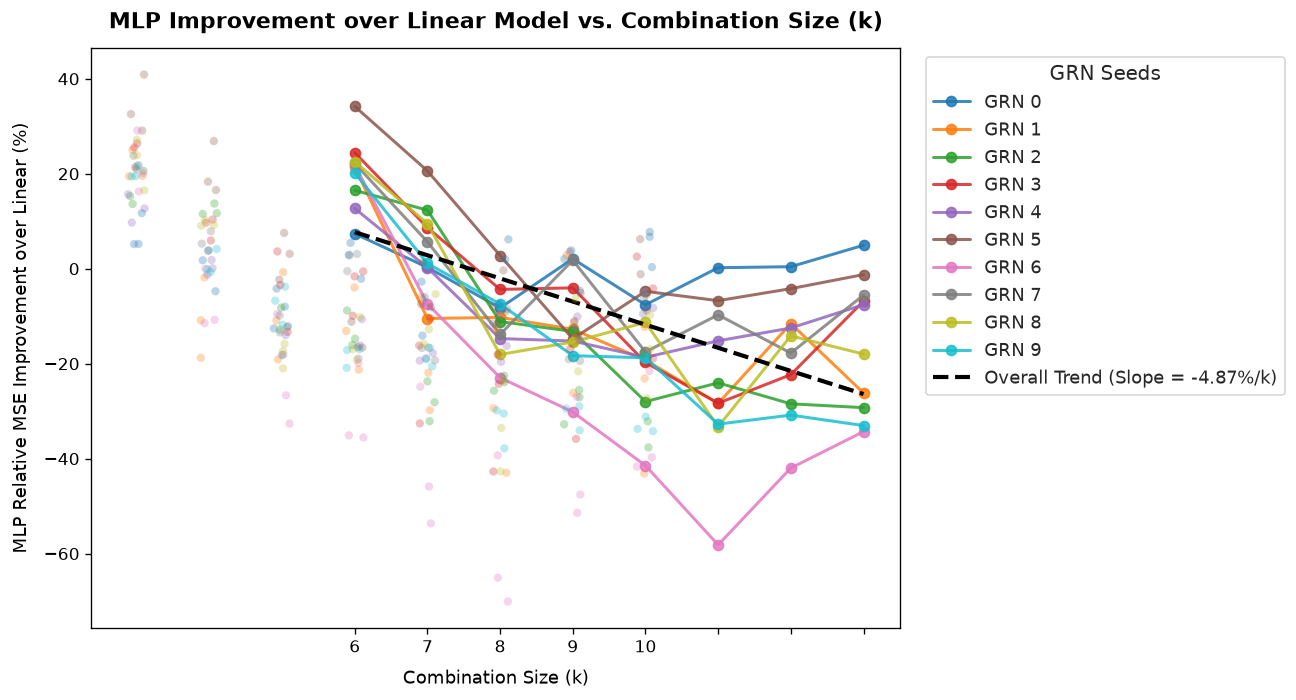

=== OVERALL TREND METRICS (Across all GRNs) ===
• Linear Trend Slope : -4.872% decrease per unit increase in k
• Pearson Correlation: r = -0.642
• Statistical Sig.  : p = 1.4044e-10

=== PER-GRN TREND BREAKDOWN ===


,GRN Seed,Slope (% per Δk),Pearson r,p-value,Decreasing?
0,0,-0.0079,-0.0035,0.9934,Yes
1,1,-4.7483,-0.7600,0.0286,Yes
2,2,-6.8783,-0.9166,0.0014,Yes
3,3,-5.4925,-0.7768,0.0233,Yes
4,4,-2.5044,-0.5837,0.1287,Yes
5,5,-4.6487,-0.7057,0.0505,Yes
6,6,-8.1299,-0.8078,0.0153,Yes
7,7,-3.7891,-0.6771,0.0651,Yes
8,8,-5.2787,-0.7365,0.0372,Yes
9,9,-7.2463,-0.9447,0.0004,Yes


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# 1. Average across the 3 training seeds for each (Network Seed, Combination Size)
ho_mean = (
    ho_df.groupby(["Network Seed", "Combination Size (k)"])[
        "MLP_vs_Linear_Improv (%)"
    ]
    .mean()
    .reset_index()
)

# 2. Calculate overall statistical trend metrics across all GRNs
slope, intercept, r_value, p_value, std_err = stats.linregress(
    ho_mean["Combination Size (k)"], ho_mean["MLP_vs_Linear_Improv (%)"]
)

# Compute per-network slopes and correlation coefficients
net_stats = []
for net in sorted(ho_mean["Network Seed"].unique()):
    net_data = ho_mean[ho_mean["Network Seed"] == net]
    s, _, r, p, _ = stats.linregress(
        net_data["Combination Size (k)"],
        net_data["MLP_vs_Linear_Improv (%)"],
    )
    net_stats.append(
        {
            "GRN Seed": net,
            "Slope (% per Δk)": s,
            "Pearson r": r,
            "p-value": p,
            "Decreasing?": "Yes" if s < 0 else "No",
        }
    )

stats_df = pd.DataFrame(net_stats)

# 3. Plotting
fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
sns.set_theme(style="whitegrid")

palette = sns.color_palette("tab10", n_colors=10)
k_values = sorted(ho_mean["Combination Size (k)"].unique())

# Plot dots for individual training runs (triplicates) with slight jitter
sns.stripplot(
    data=ho_df,
    x="Combination Size (k)",
    y="MLP_vs_Linear_Improv (%)",
    hue="Network Seed",
    palette=palette,
    alpha=0.3,
    jitter=0.12,
    size=5,
    legend=False,
    ax=ax,
)

# Plot lines connecting mean values for each GRN network seed
for net in sorted(ho_mean["Network Seed"].unique()):
    net_data = ho_mean[ho_mean["Network Seed"] == net]
    ax.plot(
        net_data["Combination Size (k)"],
        net_data["MLP_vs_Linear_Improv (%)"],
        marker="o",
        linewidth=1.8,
        markersize=6,
        alpha=0.85,
        label=f"GRN {net}",
        color=palette[net % 10],
    )

# Overlay overall linear regression trend line
x_trend = np.array(k_values)
y_trend = intercept + slope * x_trend
ax.plot(
    x_trend,
    y_trend,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Overall Trend (Slope = {slope:.2f}%/k)",
)

# Axis labels and title
ax.set_title(
    "MLP Improvement over Linear Model vs. Combination Size (k)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Combination Size (k)", fontsize=11, labelpad=8)
ax.set_ylabel(
    "MLP Relative MSE Improvement over Linear (%)", fontsize=11, labelpad=8
)
ax.set_xticks(k_values)
ax.legend(
    bbox_to_anchor=(1.02, 1), loc="upper left", title="GRN Seeds", frameon=True
)

plt.tight_layout()
plt.show()

# 4. Display Statistical Summary
print("=== OVERALL TREND METRICS (Across all GRNs) ===")
print(f"• Linear Trend Slope : {slope:.3f}% decrease per unit increase in k")
print(f"• Pearson Correlation: r = {r_value:.3f}")
print(f"• Statistical Sig.  : p = {p_value:.4e}")

print("\n=== PER-GRN TREND BREAKDOWN ===")
display(stats_df.round(4))

In [6]:
import numpy as np
import pandas as pd

ram_metrics = []

# Evaluate k=2 (Double KO) using the variables sitting in RAM
add_k2 = y_single_ko[pairs[:, 0]] + y_single_ko[pairs[:, 1]] - y_wt
mse_k2 = float(np.mean((add_k2 - y_double_ko) ** 2))

ram_metrics.append({
    "Combination Size (k)": 2,
    "Additive Baseline MSE": mse_k2,
    "Additive Baseline RMSE": mse_k2 ** 0.5
})

# Evaluate k=3 through 10
for i, set_size in enumerate(range(3, 11)):
    select_sets_arr = all_select_sets[i]
    y_true = higher_expression[set_size]
    
    # Additive Baseline formula: sum(Single KOs) - (k - 1) * WT
    additive = y_single_ko[select_sets_arr].sum(axis=1) - (set_size - 1) * y_wt
    
    add_mse = float(np.mean((additive - y_true) ** 2))
    
    ram_metrics.append({
        "Combination Size (k)": set_size,
        "Additive Baseline MSE": add_mse,
        "Additive Baseline RMSE": add_mse ** 0.5
    })

df_ram = pd.DataFrame(ram_metrics)
display(df_ram.round(6))

,Combination Size (k),Additive Baseline MSE,Additive Baseline RMSE
0,2,0.006071,0.077918
1,3,0.021289,0.145909
2,4,0.023981,0.154858
3,5,0.034190,0.184904
4,6,0.055604,0.235805
5,7,0.085860,0.293019
6,8,0.092273,0.303764
7,9,0.110398,0.332262
8,10,0.125128,0.353735


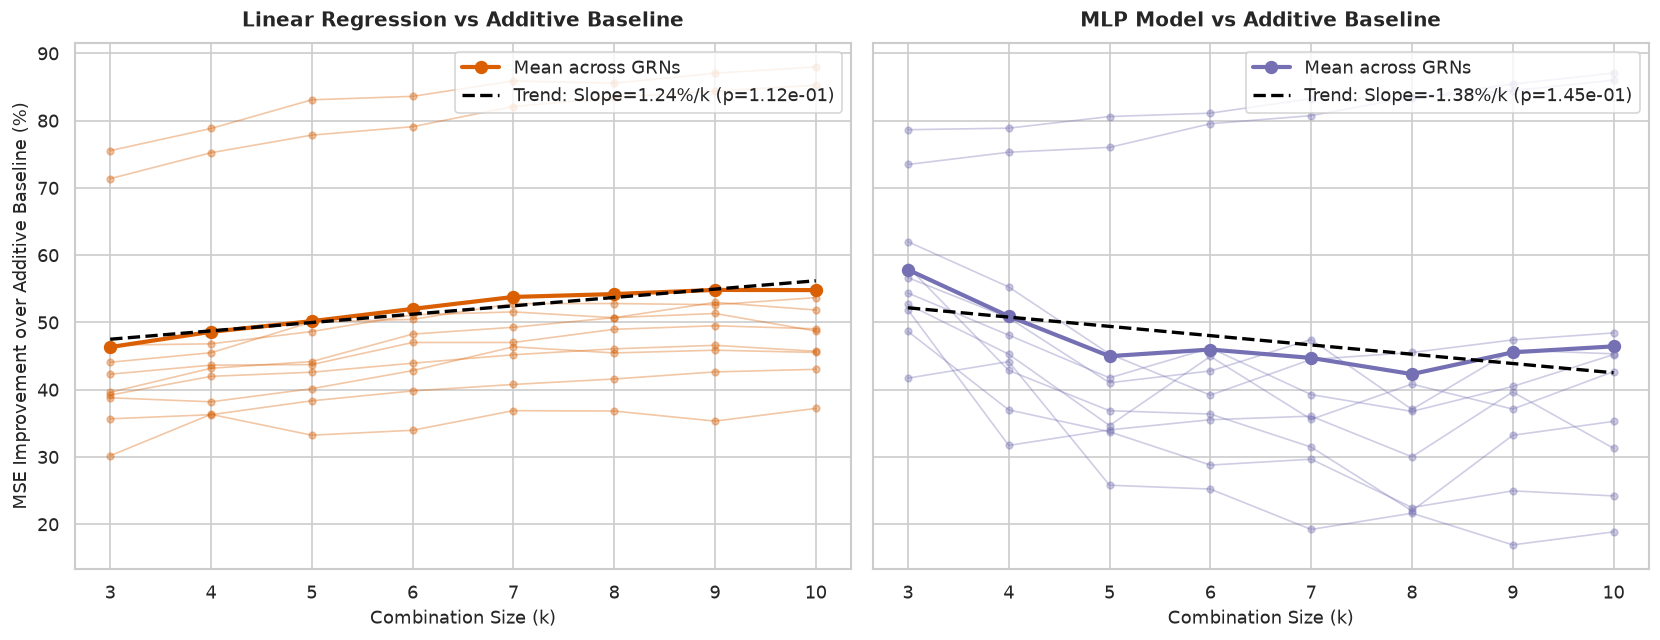

=== TREND SIGNIFICANCE SUMMARY ===


,Model,Mean Slope (% / Δk),Regression p-value,Spearman ρ,Spearman p-value,Significant Trend (p < 0.05)?
0,Linear vs Additive,1.2416,0.1115,0.3267,0.0031,No
1,MLP vs Additive,-1.3798,0.1454,-0.2414,0.0310,No



=== SLOPE COMPARISON (MLP Degradation Rate vs. Linear Degradation Rate) ===
• Mean Linear Slope : 1.242% per Δk
• Mean MLP Slope    : -1.380% per Δk
• Paired t-test     : t = -5.638, p-value = 3.1863e-04
• Conclusion       : The rate of change across set sizes is significantly different between models (MLP changes faster).


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# ============================================================
# 1. PREPARE DATA (Average across 3 training seeds per GRN)
# ============================================================
ho_models_mean = (
    ho_df.groupby(["Network Seed", "Combination Size (k)"])[
        ["Linear Improv (%)", "MLP Improv (%)"]
    ]
    .mean()
    .reset_index()
)

k_values = sorted(ho_models_mean["Combination Size (k)"].unique())

# ============================================================
# 2. STATISTICAL SIGNIFICANCE TESTS
# ============================================================
def analyze_model_trend(df, col_name, model_label):
    # Overall linear regression across all GRNs
    slope, intercept, r_val, p_val_reg, std_err = stats.linregress(
        df["Combination Size (k)"], df[col_name]
    )
    # Overall Spearman rank correlation (monotonic trend test)
    rho, p_val_spearman = stats.spearmanr(df["Combination Size (k)"], df[col_name])
    
    # Per-network slopes
    net_slopes = []
    for net in range(10):
        sub = df[df["Network Seed"] == net]
        s, _, _, _, _ = stats.linregress(sub["Combination Size (k)"], sub[col_name])
        net_slopes.append(s)
        
    return {
        "Model": model_label,
        "Mean Slope (% / Δk)": slope,
        "Regression p-value": p_val_reg,
        "Spearman ρ": rho,
        "Spearman p-value": p_val_spearman,
        "Significant Trend (p < 0.05)?": "Yes" if p_val_reg < 0.05 else "No",
        "Per-Network Slopes": net_slopes
    }

mlp_stats = analyze_model_trend(ho_models_mean, "MLP Improv (%)", "MLP vs Additive")
lin_stats = analyze_model_trend(ho_models_mean, "Linear Improv (%)", "Linear vs Additive")

# Paired t-test comparing whether MLP slope differs significantly from Linear slope
slope_diff_t, slope_diff_p = stats.ttest_rel(
    mlp_stats["Per-Network Slopes"], lin_stats["Per-Network Slopes"]
)

# ============================================================
# 3. PLOTTING COMPARATIVE TRENDS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120, sharey=True)
sns.set_theme(style="whitegrid")

models_to_plot = [
    ("Linear Improv (%)", "Linear Regression vs Additive Baseline", axes[0], "#d95f02", lin_stats),
    ("MLP Improv (%)", "MLP Model vs Additive Baseline", axes[1], "#7570b3", mlp_stats)
]

for col_name, title, ax, color, stat_dict in models_to_plot:
    # Individual GRN trajectories
    for net in range(10):
        sub = ho_models_mean[ho_models_mean["Network Seed"] == net]
        ax.plot(
            sub["Combination Size (k)"],
            sub[col_name],
            marker="o",
            markersize=4,
            linewidth=1,
            alpha=0.35,
            color=color
        )
    
    # Overall Mean across all GRNs
    overall_mean = ho_models_mean.groupby("Combination Size (k)")[col_name].mean()
    ax.plot(
        k_values,
        overall_mean,
        marker="o",
        markersize=7,
        linewidth=2.5,
        color=color,
        label=f"Mean across GRNs"
    )
    
    # Linear Trendline
    slope = stat_dict["Mean Slope (% / Δk)"]
    p_val = stat_dict["Regression p-value"]
    
    # Fit trend line
    z = np.polyfit(ho_models_mean["Combination Size (k)"], ho_models_mean[col_name], 1)
    p = np.poly1d(z)
    ax.plot(k_values, p(k_values), "--", color="black", linewidth=2, 
            label=f"Trend: Slope={slope:.2f}%/k (p={p_val:.2e})")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Combination Size (k)", fontsize=11)
    ax.set_xticks(k_values)
    ax.legend(loc="upper right", frameon=True)

axes[0].set_ylabel("MSE Improvement over Additive Baseline (%)", fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================
# 4. SUMMARY STATISTICAL REPORT
# ============================================================
summary_df = pd.DataFrame([lin_stats, mlp_stats]).drop(columns=["Per-Network Slopes"])

print("=== TREND SIGNIFICANCE SUMMARY ===")
display(summary_df.round(4))

print("\n=== SLOPE COMPARISON (MLP Degradation Rate vs. Linear Degradation Rate) ===")
print(f"• Mean Linear Slope : {lin_stats['Mean Slope (% / Δk)']:.3f}% per Δk")
print(f"• Mean MLP Slope    : {mlp_stats['Mean Slope (% / Δk)']:.3f}% per Δk")
print(f"• Paired t-test     : t = {slope_diff_t:.3f}, p-value = {slope_diff_p:.4e}")
if slope_diff_p < 0.05:
    faster_model = "MLP" if abs(mlp_stats['Mean Slope (% / Δk)']) > abs(lin_stats['Mean Slope (% / Δk)']) else "Linear"
    print(f"• Conclusion       : The rate of change across set sizes is significantly different between models ({faster_model} changes faster).")
else:
    print("• Conclusion       : No statistically significant difference in slope between MLP and Linear models.")